# Mutation-spectrum gradient along single-stranded exposure

This notebook pools all vertebrate classes available in the input and asks whether selected heavy-strand mutation components change from the beginning to the end of the mitochondrial major replication arc. The reference analysis places COX1, COX3, and CytB at the beginning, middle, and end of that arc, respectively ([Molecular Biology and Evolution paper](https://academic.oup.com/mbe/article/42/2/msae261/7998442); [analysis repository](https://github.com/mitoclub/mtdna-192component-mutspec-chordata)).

The x-axis is an illustrative **DssH proxy**, not a measured time for each species. For the three major-arc genes it is calculated as $2(p-OriL)/L$, where $p$ is the midpoint of the human rCRS locus, $OriL=5730$, and $L=16569$ ([DssH method](https://pmc.ncbi.nlm.nih.gov/articles/PMC2943950/)). Coordinates come from NCBI rCRS annotations for [COX1](https://www.ncbi.nlm.nih.gov/gene/4512), [COX3](https://www.ncbi.nlm.nih.gov/gene/4514), and [CytB](https://www.ncbi.nlm.nih.gov/gene/4519/). These same human-reference values are applied to every vertebrate and therefore represent gene position, not species-specific exposure.

ND2 is excluded because it lies on the minor arc under this model; ND6 has no spectrum in the input table.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display


def find_project_root(start=Path.cwd()):
    """Find the repository from either its root or this analysis folder."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "1init_data" / "data" / "MutSpecVertebrates12.csv.gz").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the project root")


ROOT = find_project_root()
COMPARISON_MODULE_DIR = ROOT / "3compare_t_genes"
if str(COMPARISON_MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(COMPARISON_MODULE_DIR))

from mutation_comparison import (
    DEFAULT_MUTATION_RATIOS,
    calculate_mutation_ratios,
    orient_substitutions_to_heavy_strand,
    plot_tsss_gradient,
    plot_tsss_ratio_gradient,
    select_common_species,
    summarize_tsss_ratio_slopes,
    summarize_tsss_slopes,
    validate_matched_spectra,
)

CLASS_FILTER = None  # Use an exact Class value here to analyse one class only.
GENES = ("CO1", "CO3", "Cytb")
MUTATIONS_TO_PLOT = ("C>T", "A>G", "G>A", "T>C")
N_BOOT = 5_000
RANDOM_STATE = 20260722
DATA_PATH = ROOT / "1init_data" / "data" / "MutSpecVertebrates12.csv.gz"
ANALYSIS_DIR = ROOT / "4tsss_gradient"
DATA_DIR = ANALYSIS_DIR / "data"
FIGURES_DIR = ANALYSIS_DIR / "figures"
for directory in (DATA_DIR, FIGURES_DIR):
    directory.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

In [2]:
MTDNA_LENGTH = 16_569
ORIL_START = 5_730
gene_metadata = pd.DataFrame(
    {
        "Gene": ["CO1", "CO3", "Cytb"],
        "display_gene": ["COX1", "COX3", "CytB"],
        "arc_position": ["beginning", "middle", "end"],
        "rCRS_start": [5904, 9207, 14747],
        "rCRS_end": [7445, 9990, 15887],
    }
)
gene_metadata["rCRS_midpoint"] = (
    gene_metadata["rCRS_start"] + gene_metadata["rCRS_end"]
) / 2
gene_metadata["dssh_proxy"] = (
    2 * (gene_metadata["rCRS_midpoint"] - ORIL_START) / MTDNA_LENGTH
)
gene_metadata["plot_label"] = (
    gene_metadata["display_gene"]
    + "\nDssH="
    + gene_metadata["dssh_proxy"].map(lambda value: f"{value:.3f}")
)
gene_metadata.to_csv(DATA_DIR / "gene_tsss_proxy.csv", index=False)
display(gene_metadata.round({"rCRS_midpoint": 1, "dssh_proxy": 3}))

,Gene,display_gene,arc_position,rCRS_start,rCRS_end,rCRS_midpoint,dssh_proxy,plot_label
0,CO1,COX1,beginning,5904,7445,6674.5,0.114,COX1\nDssH=0.114
1,CO3,COX3,middle,9207,9990,9598.5,0.467,COX3\nDssH=0.467
2,Cytb,CytB,end,14747,15887,15317.0,1.157,CytB\nDssH=1.157


In [3]:
spectra = pd.read_csv(DATA_PATH)
analysis_spectra = (
    spectra.copy()
    if CLASS_FILTER is None
    else spectra.loc[spectra["Class"].eq(CLASS_FILTER)].copy()
)
scope_label = "all vertebrates" if CLASS_FILTER is None else CLASS_FILTER
matched_raw, common_species = select_common_species(analysis_spectra, GENES)
matched = orient_substitutions_to_heavy_strand(matched_raw)
matched_info = validate_matched_spectra(matched, genes=GENES)

matched_cohort = (
    matched_raw[["Species", "Class"]]
    .drop_duplicates()
    .sort_values(["Class", "Species"])
)
matched_cohort.to_csv(
    DATA_DIR / "matched_species_CO1_CO3_Cytb.csv", index=False
)
class_counts = (
    matched_cohort.groupby("Class", as_index=False)
    .size()
    .rename(columns={"size": "n_common_species"})
    .sort_values("n_common_species", ascending=False)
)
class_counts.to_csv(
    DATA_DIR / "matched_class_counts_CO1_CO3_Cytb.csv", index=False
)
print(
    f"Exact all-three-gene intersection: N = {matched_info.n_species} "
    f"species across {scope_label}"
)
display(class_counts.reset_index(drop=True))

Exact all-three-gene intersection: N = 85 species across all vertebrates


,Class,n_common_species
0,Mammalia,52
1,Actinopteri,19
2,Aves,8
3,Amphibia,4
4,Lepidosauria,2


## Descriptive mutation gradients

Faint trajectories connect the same species across genes. Colored points and whiskers are gene means and 95% species-cluster bootstrap intervals. The four panels form two complementary heavy-strand mutation pairs.

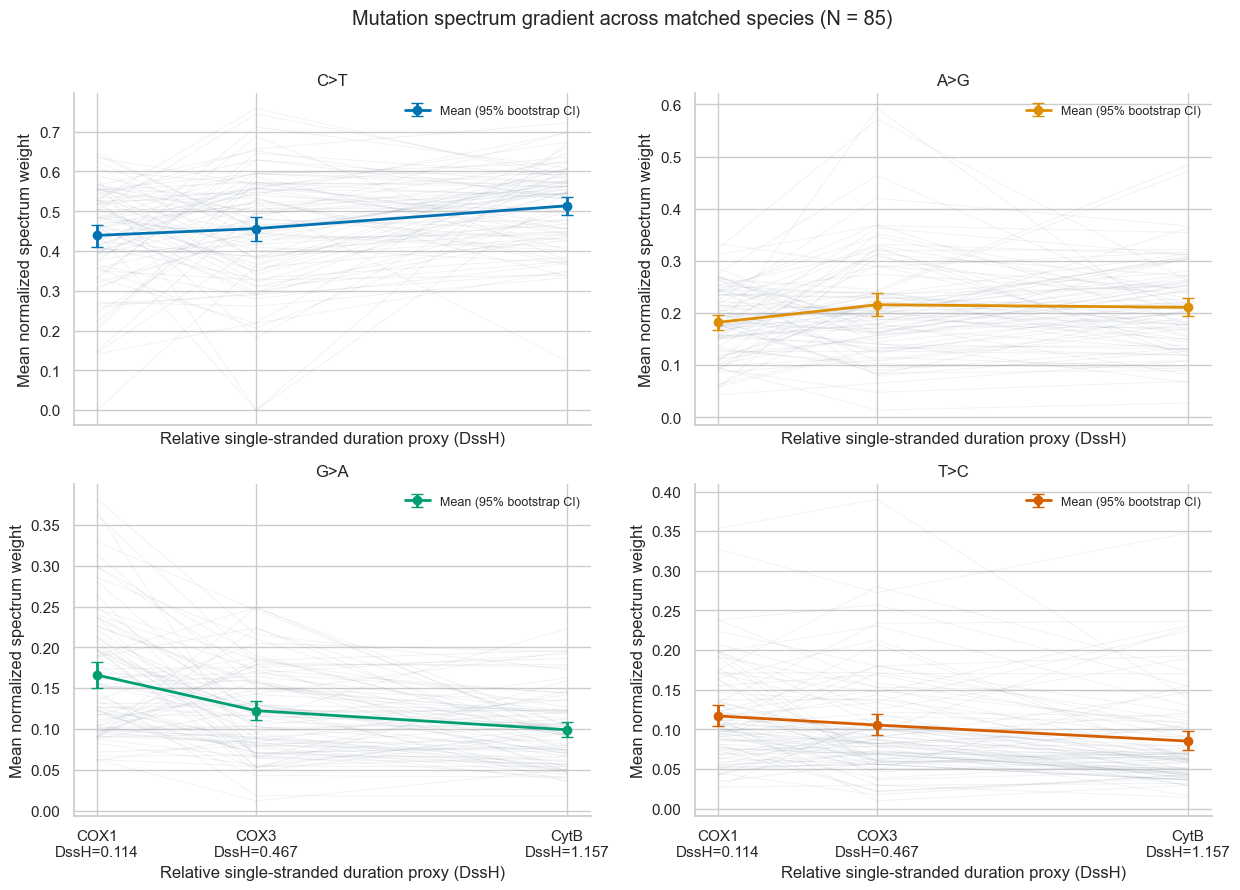

In [4]:
gradient_plot = plot_tsss_gradient(
    matched,
    gene_metadata,
    genes=GENES,
    mutations=MUTATIONS_TO_PLOT,
    tsss_col="dssh_proxy",
    label_col="plot_label",
    n_boot=N_BOOT,
    random_state=RANDOM_STATE,
)
gradient_plot.fig.savefig(
    FIGURES_DIR / "tsss_gradient_selected_mutations.png",
    dpi=300, bbox_inches="tight",
)
gradient_summary = gradient_plot.summary.merge(
    gene_metadata.drop(columns="plot_label"), on=["Gene", "dssh_proxy"],
    validate="many_to_one",
)
gradient_summary.to_csv(
    DATA_DIR / "tsss_gradient_gene_summary.csv", index=False
)
plt.show()

In [5]:
mean_table = (
    gradient_summary.pivot(index="Mut", columns="display_gene", values="estimate")
    .reindex(index=MUTATIONS_TO_PLOT, columns=["COX1", "COX3", "CytB"])
)
mean_table["CytB_minus_COX1"] = mean_table["CytB"] - mean_table["COX1"]
print("Mean normalized spectrum weights and endpoint change")
display(mean_table.round(4))

slope_summary = summarize_tsss_slopes(
    matched,
    gene_metadata,
    genes=GENES,
    mutations=MUTATIONS_TO_PLOT,
    tsss_col="dssh_proxy",
    label_col="display_gene",
    n_boot=N_BOOT,
    random_state=RANDOM_STATE,
)
slope_summary.to_csv(DATA_DIR / "tsss_gradient_slope_summary.csv", index=False)
print("Within-species slopes along the DssH proxy")
display(slope_summary.round(4))

Mean normalized spectrum weights and endpoint change


display_gene,COX1,COX3,CytB,CytB_minus_COX1
Mut,,,,
C>T,0.4394,0.4564,0.5137,0.0744
A>G,0.1821,0.2159,0.2109,0.0288
G>A,0.1660,0.1224,0.0990,-0.0670
T>C,0.1168,0.1054,0.0852,-0.0317


Within-species slopes along the DssH proxy


,Mut,n_species,mean_slope_per_proxy_unit,ci_low,ci_high,median_species_slope,fraction_species_positive,confidence
0,C>T,85,0.0729,0.0450,0.1015,0.0657,0.7059,0.95
1,A>G,85,0.0228,0.0066,0.0393,0.0191,0.5882,0.95
2,G>A,85,-0.0601,-0.0735,-0.0472,-0.0525,0.1176,0.95
3,T>C,85,-0.0302,-0.0407,-0.0196,-0.0264,0.2235,0.95


## Opportunity-adjusted burdens without 100% closure

The source workflow first calculates `Observed / Expected` and only then rescales the 12 components to sum to one. Here `OpportunityAdjusted = Observed.fillna(0) / Expected` retains that pre-normalization value. It adjusts reconstructed substitution burden for the available synonymous opportunities but does **not** estimate an absolute mutation frequency or mutation rate. Expected opportunities are required to be finite and strictly positive.

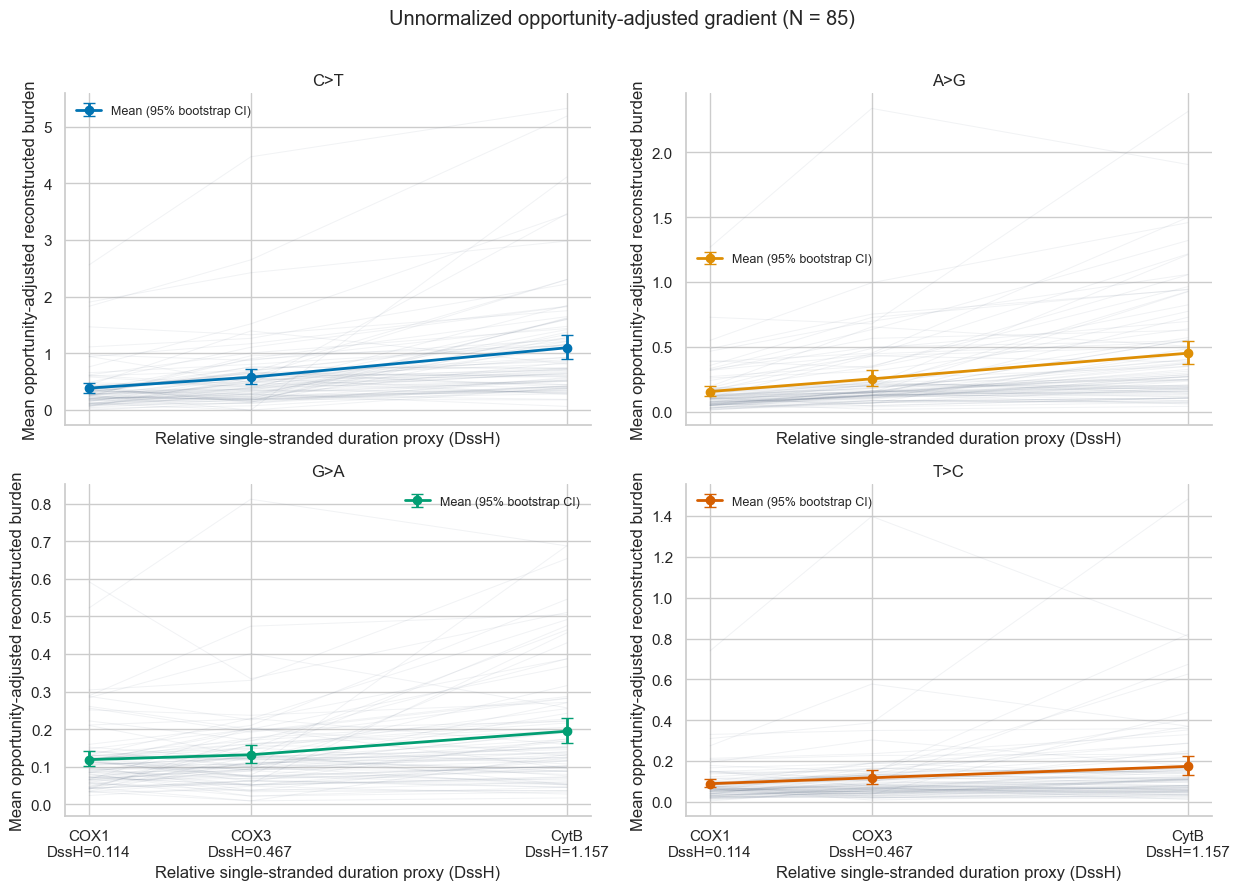

,Mut,n_species,mean_slope_per_proxy_unit,ci_low,ci_high,median_species_slope,fraction_species_positive,confidence
0,C>T,85,0.6915,0.5415,0.8624,0.4176,0.9647,0.95
1,A>G,85,0.2834,0.2214,0.3503,0.1878,0.9529,0.95
2,G>A,85,0.0748,0.0504,0.1034,0.0353,0.7294,0.95
3,T>C,85,0.0810,0.0476,0.1236,0.0287,0.7647,0.95


In [6]:
expected = pd.to_numeric(matched["Expected"], errors="raise")
observed = pd.to_numeric(matched["Observed"], errors="raise").fillna(0)
if (not np.isfinite(expected).all()) or expected.le(0).any():
    raise ValueError("Expected opportunities must be finite and strictly positive")
if (not np.isfinite(observed).all()) or observed.lt(0).any():
    raise ValueError("Observed reconstructed burdens must be finite and non-negative")

matched_opportunity_adjusted = matched.copy()
matched_opportunity_adjusted["OpportunityAdjusted"] = observed / expected
opportunity_adjusted_values = matched_opportunity_adjusted.loc[
    matched_opportunity_adjusted["Mut"].isin(MUTATIONS_TO_PLOT),
    ["Species", "Class", "Gene", "Mut", "Observed", "Expected", "OpportunityAdjusted"],
].sort_values(["Mut", "Species", "Gene"])
opportunity_adjusted_values.to_csv(
    DATA_DIR / "tsss_opportunity_adjusted_species_values.csv", index=False
)

opportunity_plot = plot_tsss_gradient(
    matched_opportunity_adjusted,
    gene_metadata,
    genes=GENES,
    mutations=MUTATIONS_TO_PLOT,
    tsss_col="dssh_proxy",
    label_col="plot_label",
    value_col="OpportunityAdjusted",
    require_sum_to_one=False,
    y_label="Mean opportunity-adjusted reconstructed burden",
    figure_title="Unnormalized opportunity-adjusted gradient",
    n_boot=N_BOOT,
    random_state=RANDOM_STATE,
)
opportunity_plot.fig.savefig(
    FIGURES_DIR / "tsss_opportunity_adjusted_selected_mutations.png",
    dpi=300, bbox_inches="tight",
)
opportunity_summary = opportunity_plot.summary.merge(
    gene_metadata.drop(columns="plot_label"), on=["Gene", "dssh_proxy"],
    validate="many_to_one",
)
opportunity_summary.to_csv(
    DATA_DIR / "tsss_opportunity_adjusted_gene_summary.csv", index=False
)
plt.show()

opportunity_slopes = summarize_tsss_slopes(
    matched_opportunity_adjusted,
    gene_metadata,
    genes=GENES,
    mutations=MUTATIONS_TO_PLOT,
    value_col="OpportunityAdjusted",
    require_sum_to_one=False,
    n_boot=N_BOOT,
    random_state=RANDOM_STATE,
)
opportunity_slopes.to_csv(
    DATA_DIR / "tsss_opportunity_adjusted_slope_summary.csv", index=False
)
display(opportunity_slopes.round(4))

## Complementary-substitution ratios within species

The ratios `C>T / G>A` and `A>G / T>C` are calculated inside every species-gene profile before species are summarized. No pseudocount is added: a non-positive denominator stops the analysis. The common per-profile normalization factor cancels algebraically, $(r_i/Z)/(r_j/Z)=r_i/r_j$, so ratios from normalized `MutSpec` and from `OpportunityAdjusted` are identical; the latter is used below to make the underlying quantities explicit.

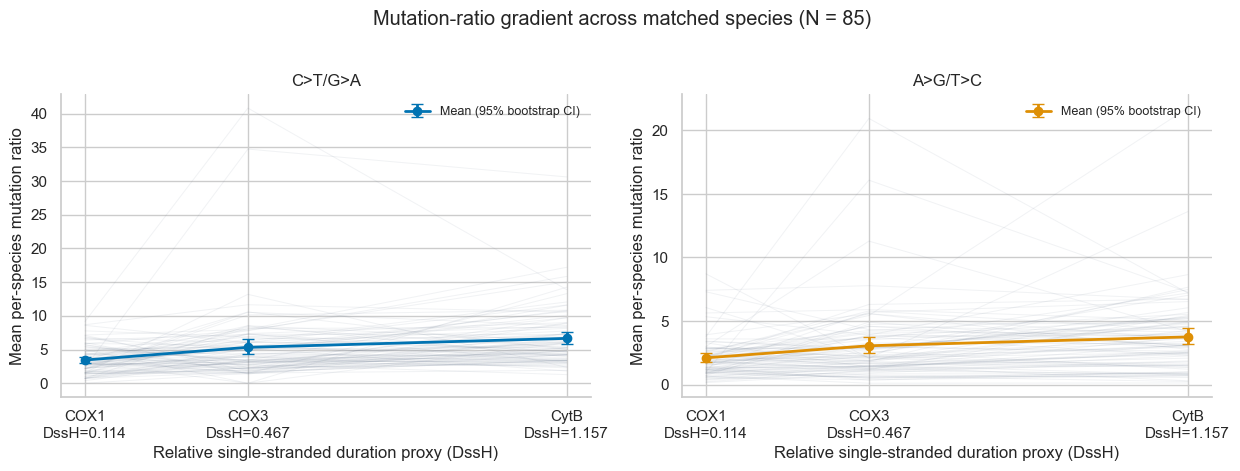

,Ratio,display_gene,estimate,ci_low,ci_high
0,C>T/G>A,COX1,3.4377,3.0084,3.8739
1,A>G/T>C,COX1,2.1003,1.7821,2.4473
2,C>T/G>A,COX3,5.3245,4.2703,6.5925
3,A>G/T>C,COX3,3.0499,2.4433,3.7555
4,C>T/G>A,CytB,6.6498,5.7769,7.6173
5,A>G/T>C,CytB,3.7452,3.1685,4.4321


,Ratio,NumeratorMut,DenominatorMut,n_species,mean_slope_per_proxy_unit,ci_low,ci_high,median_species_slope,fraction_species_positive,confidence
0,C>T/G>A,C>T,G>A,85,2.9193,2.1139,3.7717,2.1239,0.8000,0.95
1,A>G/T>C,A>G,T>C,85,1.4983,0.9486,2.1490,1.1698,0.7294,0.95


In [7]:
ratio_values = calculate_mutation_ratios(
    matched_opportunity_adjusted,
    genes=GENES,
    ratios=DEFAULT_MUTATION_RATIOS,
    value_col="OpportunityAdjusted",
    require_sum_to_one=False,
    zero_denominator="raise",
)
ratio_values.to_csv(DATA_DIR / "tsss_mutation_ratio_species_values.csv", index=False)

normalized_ratio_values = calculate_mutation_ratios(
    matched, genes=GENES, ratios=DEFAULT_MUTATION_RATIOS
)
np.testing.assert_allclose(
    ratio_values["RatioValue"], normalized_ratio_values["RatioValue"],
    rtol=1e-10, atol=1e-12,
)

ratio_plot = plot_tsss_ratio_gradient(
    matched_opportunity_adjusted,
    gene_metadata,
    genes=GENES,
    ratios=DEFAULT_MUTATION_RATIOS,
    tsss_col="dssh_proxy",
    label_col="plot_label",
    value_col="OpportunityAdjusted",
    require_sum_to_one=False,
    zero_denominator="raise",
    n_boot=N_BOOT,
    random_state=RANDOM_STATE,
)
ratio_plot.fig.savefig(
    FIGURES_DIR / "tsss_mutation_ratio_gradient.png",
    dpi=300, bbox_inches="tight",
)
ratio_summary = ratio_plot.summary.merge(
    gene_metadata.drop(columns="plot_label"), on=["Gene", "dssh_proxy"],
    validate="many_to_one",
)
ratio_summary.to_csv(DATA_DIR / "tsss_mutation_ratio_gene_summary.csv", index=False)
plt.show()

ratio_slopes = summarize_tsss_ratio_slopes(
    matched_opportunity_adjusted,
    gene_metadata,
    genes=GENES,
    ratios=DEFAULT_MUTATION_RATIOS,
    value_col="OpportunityAdjusted",
    require_sum_to_one=False,
    zero_denominator="raise",
    n_boot=N_BOOT,
    random_state=RANDOM_STATE,
)
ratio_slopes.to_csv(DATA_DIR / "tsss_mutation_ratio_slope_summary.csv", index=False)
display(ratio_summary[["Ratio", "display_gene", "estimate", "ci_low", "ci_high"]].round(4))
display(ratio_slopes.round(4))

## Interpretation limits

This is an exploratory positional gradient across only three genes. Gene identity, sequence composition, genomic position, and TSSS are confounded; vertebrates are phylogenetically non-independent and class representation is strongly unbalanced. Normalized spectrum weights additionally sum to one; the opportunity-adjusted analysis avoids this 100% closure but remains a reconstructed relative burden, not an absolute mutation rate. Ratios can be skewed and sensitive to small denominators, so species trajectories and denominator values are retained with the summaries. Human rCRS coordinates, mtDNA length, and OriL are reused for all classes even though mitogenome organization can differ among vertebrates. These plots can reveal descriptive pooled patterns, but cannot establish a causal TSSS effect. Species-specific coordinates and a class-aware, phylogeny-aware model are needed for confirmatory inference.